In [17]:
#import the relevant functions
from modify_acudata import *
from datetime import datetime
from glob import glob
import numpy as np
try:
    import spt3g.core as g3
except Exception:
    import g3

In [18]:
bookloc = "data/shwetha/bb_output/bbv0/"
bookfiles = sorted(glob(bookloc+"D_*"))

In [19]:
def get_streams(files, channel_idx=0):
    """Iterate g3 files and collect per-scan arrays for az, el, I, Q, and times."""
    azarr = []
    elarr = []
    Iarr = []
    Qarr = []
    tarr = []
    for file in files:
        print(f"Processing {file}")
        try:
            g3f = g3.G3File(file)
        except Exception as e:
            print(f"Could not open {file}: {e}")
            continue
        for frame in g3f:
            try:
                if frame.type != g3.G3FrameType.Scan:
                    continue
            except Exception:
                continue
            ancil = frame.get('ancil')
            signal = frame.get('signal')
            if ancil is None or signal is None:
                continue
            az = np.asarray(ancil.get('az_enc', []))
            el = np.asarray(ancil.get('el_enc', []))
            times = np.asarray(signal.times) / g3.G3Units.s
            data = np.asarray(signal.data)
            if data.ndim == 2:
                chI = 2 * channel_idx
                chQ = chI + 1
                if chI < data.shape[0]:
                    I_ch = data[chI]
                else:
                    I_ch = np.zeros_like(times)
                if chQ < data.shape[0]:
                    Q_ch = data[chQ]
                else:
                    Q_ch = np.zeros_like(times)
            else:
                I_ch = data
                Q_ch = np.zeros_like(data)
            azarr.append(az)
            elarr.append(el)
            Iarr.append(I_ch)
            Qarr.append(Q_ch)
            tarr.append(times)
    return azarr, elarr, Iarr, Qarr, tarr

In [ ]:
# Quick diagnostics: inspect the first file to see what frames/keys it contains
if len(bookfiles) == 0:
    print('No book files found at', bookloc)
else:
    first = bookfiles[0]
    print('Inspecting first file:', first)
    try:
        g3f = g3.G3File(first)
    except Exception as e:
        print('Failed to open g3 file:', e)
        g3f = None
    if g3f is not None:
        counts = {}
        for i, frame in enumerate(g3f):
            t = getattr(frame, 'type', 'UNKNOWN')
            counts[t] = counts.get(t, 0) + 1
            if i < 20:
                try:
                    keys = list(frame.keys())
                except Exception:
                    keys = []
                print(f'Frame {i}: type={t}, keys={keys}')
            if i == 0 and getattr(frame, 'type', None) == g3.G3FrameType.Scan:
                ancil = frame.get('ancil')
                signal = frame.get('signal')
                print('First Scan frame ancil keys:', list(ancil.keys()) if ancil else 'None')
                if signal is not None:
                    data = np.asarray(signal.data)
                    print('signal.data.shape =', getattr(data, 'shape', 'unknown'))
                    print('len(signal.times) =', len(signal.times) if hasattr(signal, 'times') else 'no times')
        print('Frame type counts:', counts)

# Now run the collector (this will still print processing info)
AZ, EL, dI, dQ, T = get_streams(bookfiles)

/tmp/ipykernel_146277/3117045315.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()
/tmp/ipykernel_146277/3117045315.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


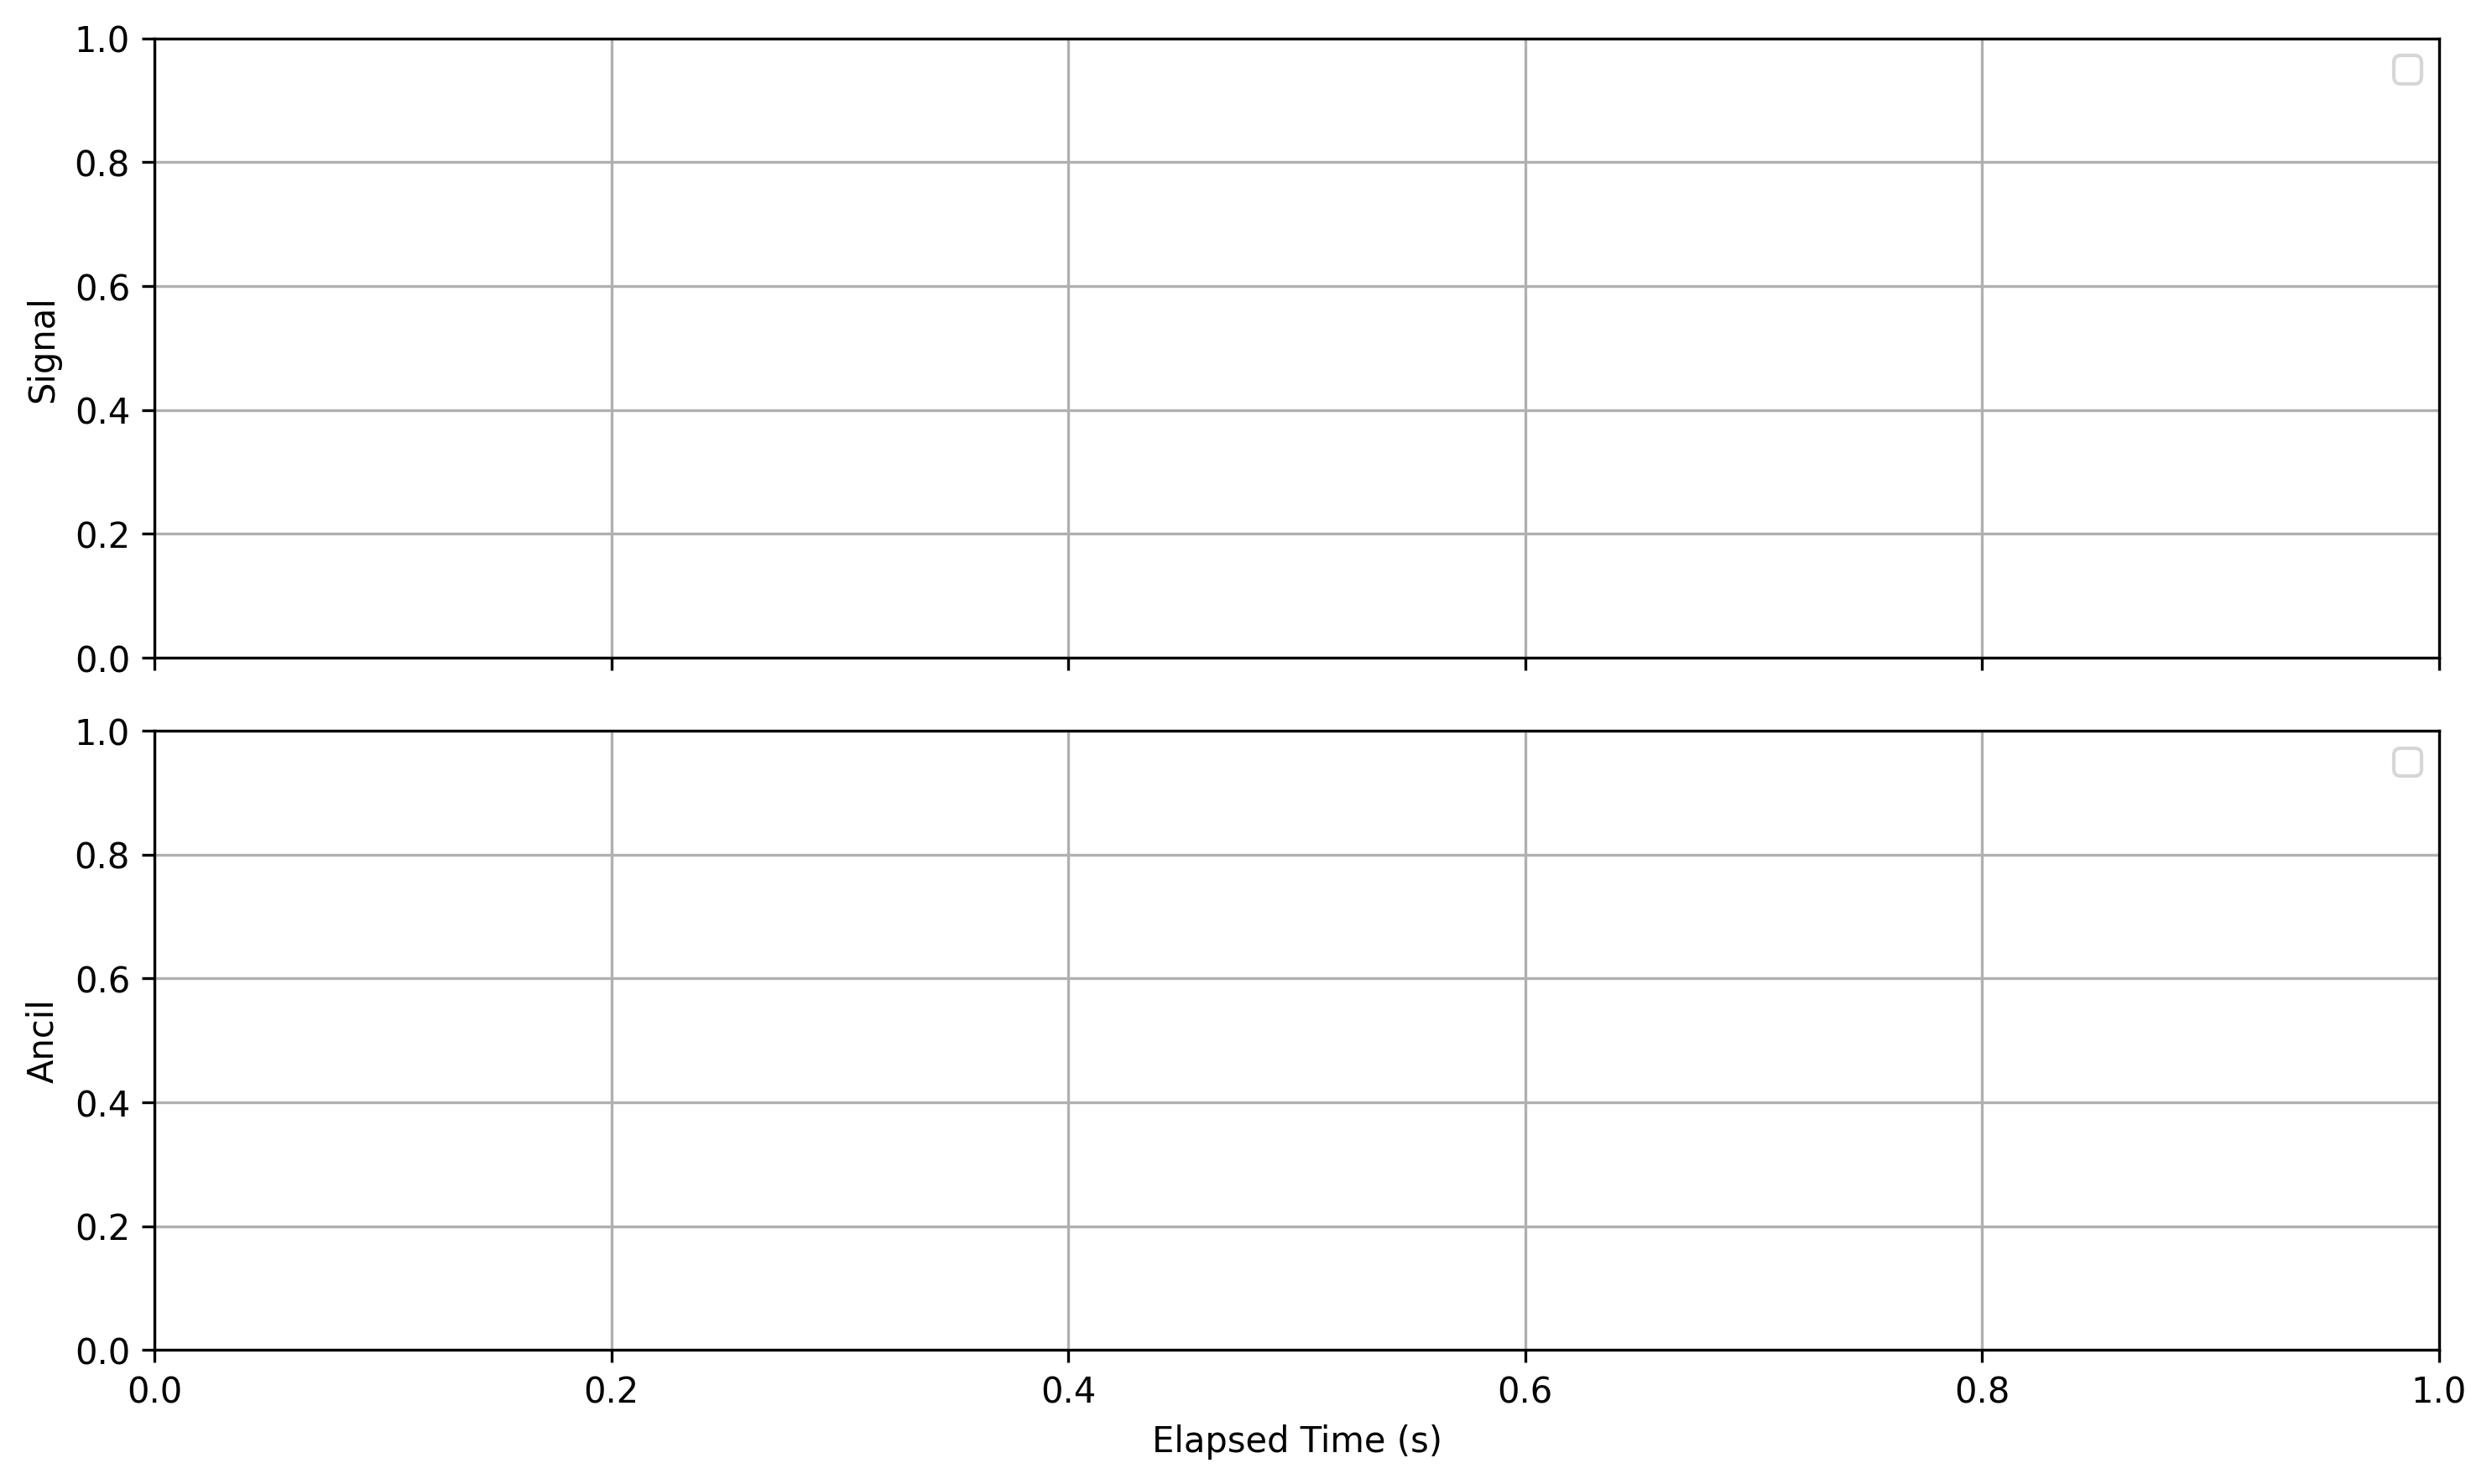

In [21]:
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rc('figure', dpi=300)

# Concatenate per-scan arrays into single time-synced streams
t_flat = np.concatenate(T) if len(T) > 0 else np.array([])
I_flat = np.concatenate(dI) if len(dI) > 0 else np.array([])
Q_flat = np.concatenate(dQ) if len(dQ) > 0 else np.array([])
AZ_flat = np.concatenate(AZ) if len(AZ) > 0 else np.array([])
EL_flat = np.concatenate(EL) if len(EL) > 0 else np.array([])

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 6))

if t_flat.size > 0:
    t0 = t_flat[0]
else:
    t0 = 0

if I_flat.size > 0:
    ax1.plot(t_flat - t0, I_flat, label='I Channel')
if Q_flat.size > 0:
    ax1.plot(t_flat - t0, Q_flat, label='Q Channel')
ax1.legend()
ax1.grid(True)
ax1.set_ylabel('Signal')

if AZ_flat.size > 0:
    ax2.plot(t_flat - t0, AZ_flat, label='Azimuth')
if EL_flat.size > 0:
    ax2.plot(t_flat - t0, EL_flat, label='Elevation')
ax2.legend()
ax2.grid(True)
ax2.set_ylabel('Ancil')

ax2.set_xlabel('Elapsed Time (s)')

plt.tight_layout()
plt.show()